# QDFL — QMF-MAP-style presentation figures & tables

This notebook regenerates the **presentation elements that appear in QMF-MAP (Li et al., *Information Fusion* 2027) but are missing from the QDFL manuscript**, computed for QDFL's own circuits and results. Run top-to-bottom on Kaggle; every figure saves to `./figs/` at 300 dpi and every table exports to LaTeX (`booktabs`) in `./tables/`.

### What this produces, and where each number comes from

| # | QMF-MAP element | QDFL analogue built here | Data source |
|---|---|---|---|
| B | Table 7 + Fig 11 — expressibility & entangling capability | Same, for QDFL's **VQC / QDCN / QDFL** circuits | **Computed from circuit definitions** (no dataset needed) |
| C | Table 9 — quantum resource scaling | Same, for QDFL's **angle-encoded** circuits | **Computed analytically** from the real circuit structure |
| F | Fig 9 / Fig 10 — boxplot & grouped-bar deltas | Distribution and family deltas of QDFL's operating-point AUC | **`QDFL_hybrid_3seed_results.csv`** (your real results) |
| D | Fig 7 — confusion matrices | Same green-shaded grid | **Renderer + hook**: needs your per-sample `(y_true, y_pred)` |
| E | Fig 8 — ROC curves | Same multi-panel grid | **Renderer + hook**: needs your per-sample `(y_true, y_score)` |
| G | Fig 12 + Table 8 — ROC-AUC under NISQ noise | Downstream-AUC degradation (QDFL currently reports *fidelity*, not AUC, under noise) | **Renderer + pipeline hook** |

### Data-provenance policy

Sections **B, C, F run immediately and use only real inputs** (circuit structure or your CSV). Sections **D, E, G are rendering scaffolds**: the plotting functions are complete and production-quality, and they are demonstrated on arrays clearly labelled `DEMO_*` so you can see the output, but those panels are **not QDFL results** until you replace the demo arrays with your pipeline's real outputs. Every such cell is marked with `# >>> REPLACE WITH YOUR REAL ARRAYS <<<`. Nothing here fabricates a fraud-detection number.

> QMF-MAP's Fig 1–6 (framework schematic and circuit diagrams) are drawn by hand in a vector editor, not generated from data, so they are out of scope here. QMF-MAP's modality boxplot (its Fig 9) and attention ablation (its Fig 10) do not transfer directly — QDFL is not multimodal and has no attention module — so section F reinterprets those *aesthetics* for QDFL's own system families and ablations.


## 0 · Setup — installs, imports, publication aesthetic

In [1]:
# Kaggle: PennyLane is the only package not pre-installed. Quiet install.
import importlib.util, subprocess, sys
if importlib.util.find_spec("pennylane") is None:
    subprocess.run([sys.executable,"-m","pip","install","-q","pennylane"], check=True)

import os, numpy as np, pandas as pd
import pennylane as qml
import matplotlib as mpl, matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy.special import rel_entr
from sklearn.metrics import roc_curve, auc as sk_auc, confusion_matrix

os.makedirs("figs", exist_ok=True); os.makedirs("tables", exist_ok=True)

# ---- publication-quality defaults (match a Times-set IEEE/Elsevier column) ----
mpl.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.family": "serif", "font.serif": ["DejaVu Serif"], "font.size": 11,
    "axes.titlesize": 11, "axes.labelsize": 11, "axes.linewidth": 0.8,
    "xtick.labelsize": 9, "ytick.labelsize": 9, "legend.fontsize": 9,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.5,
    "axes.spines.top": False, "axes.spines.right": False,
})
# QMF-MAP palette
GREEN = LinearSegmentedColormap.from_list("qmfgreen",
        ["#f7fcf5","#e5f5e0","#c7e9c0","#a1d99b","#74c476","#41ab5d","#238b45","#006d2c"])
PAL = {"vqc":"#4c78b0","qdcn":"#5aa469","qdfl":"#8e6fb3","pool":"#f0883e",
       "base":"#f4a7a3","prop":"#4c78b0"}

def savefig(fig, name):
    p=f"figs/{name}.png"; fig.savefig(p); fig.savefig(f"figs/{name}.pdf")
    print("saved", p); return p

def to_latex(df, name, caption, label, float_fmt="%.4f"):
    tex=df.to_latex(index=False, escape=True, caption=caption, label=label,
                    column_format="l"+"c"*(df.shape[1]-1), float_format=lambda x: float_fmt%x,
                    bold_rows=False)
    open(f"tables/{name}.tex","w").write(tex); print("wrote tables/%s.tex"%name)
    return tex

RNG = np.random.default_rng(42)
print("setup complete · pennylane", qml.version())

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 52.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 43.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 67.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 81.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 100.6 MB/s eta 0:00:00
setup complete · pennylane 0.45.1


## A · QDFL circuit definitions

These are QDFL's **actual** circuits, transcribed from `qdfl-hybrid.ipynb`:

- **VQC** — 8 qubits, `AngleEmbedding(Y)` → `StronglyEntanglingLayers` (3 layers). 72 quantum parameters.
- **QDCN** — two 4-qubit channels: A = `AngleEmbedding(Y)`→`BasicEntanglerLayers`(2)→⟨Z⟩; B = `AngleEmbedding(X)`→CNOT chain→`BasicEntanglerLayers`(2)→⟨Y⟩. 16 quantum parameters.
- **QDFL** — same dual-channel structure as QDCN but `BasicEntanglerLayers`(**3**). 24 quantum parameters.

All three are angle-encoded (one qubit per feature), which is why the resource scaling in section C differs from QMF-MAP's amplitude-encoding `⌈log₂ D⌉`.

In [2]:
N_VQC   = 8      # VQC qubits
N_CH    = 4      # per-channel qubits (QDCN / QDFL)
L_VQC   = 3      # StronglyEntangling layers
L_QDCN  = 2      # BasicEntangler layers (QDCN)
L_QDFL  = 3      # BasicEntangler layers (QDFL)

def _vqc_state(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(N_VQC), rotation="Y")
    qml.StronglyEntanglingLayers(weights, wires=range(N_VQC))

def _basic_channel_state(inputs, weights, n_wires, rotation, cnot_chain=False):
    qml.AngleEmbedding(inputs, wires=range(n_wires), rotation=rotation)
    if cnot_chain:
        for q in range(n_wires-1): qml.CNOT(wires=[q, q+1])
    qml.BasicEntanglerLayers(weights, wires=range(n_wires))

def make_state_qnode(kind):
    '''Return (qnode, weight_shape, n_wires) for kind in {vqc, qdcn_a, qdcn_b, qdfl_a, qdfl_b}.'''
    if kind=="vqc":
        n=N_VQC; dev=qml.device("default.qubit", wires=n)
        wshape=qml.StronglyEntanglingLayers.shape(n_layers=L_VQC, n_wires=n)
        @qml.qnode(dev)
        def q(inputs, weights): _vqc_state(inputs, weights); return qml.state()
        return q, wshape, n
    n=N_CH; dev=qml.device("default.qubit", wires=n)
    L = L_QDCN if kind.startswith("qdcn") else L_QDFL
    rot = "Y" if kind.endswith("_a") else "X"
    chain = kind.endswith("_b")
    wshape=qml.BasicEntanglerLayers.shape(n_layers=L, n_wires=n)
    @qml.qnode(dev)
    def q(inputs, weights): _basic_channel_state(inputs, weights, n, rot, chain); return qml.state()
    return q, wshape, n

print("circuits defined:", ["vqc","qdcn_a","qdcn_b","qdfl_a","qdfl_b"])

circuits defined: ['vqc', 'qdcn_a', 'qdcn_b', 'qdfl_a', 'qdfl_b']


## B · Expressibility & entangling capability  →  *QMF-MAP Table 7 + Fig 11*

Two standard circuit descriptors (Sim, Johnson & Aspuru-Guzik, *Adv. Quantum Technol.* 2019):

- **Entangling capability** — the Meyer–Wallach measure $Q$ averaged over random parameter samples; $Q=0$ for product states, $Q\to1$ for maximally entangled. Higher is better.
- **Expressibility** — the KL divergence between the circuit's output-state fidelity distribution and the Haar distribution; **lower is better** (closer to Haar-random coverage of state space).

Both are computed by sampling QDFL's real circuits at random inputs and parameters — no dataset required.

In [3]:
def meyer_wallach(state, n):
    psi=state.reshape([2]*n); s=0.0
    for k in range(n):
        ax=[i for i in range(n) if i!=k]
        rho=np.tensordot(psi, np.conj(psi), axes=(ax,ax))
        s+=np.real(np.trace(rho@rho))
    return float(2*(1-s/n))

def entangling_samples(kind, n_samples=400):
    q,wshape,n=make_state_qnode(kind); out=np.empty(n_samples)
    for i in range(n_samples):
        inp=RNG.uniform(0,2*np.pi,size=n); w=RNG.uniform(0,2*np.pi,size=wshape)
        out[i]=meyer_wallach(np.asarray(q(inp,w)), n)
    return out

def expressibility_kl(kind, n_pairs=1200, bins=75):
    q,wshape,n=make_state_qnode(kind); fids=np.empty(n_pairs)
    for i in range(n_pairs):
        i1=RNG.uniform(0,2*np.pi,size=n); w1=RNG.uniform(0,2*np.pi,size=wshape)
        i2=RNG.uniform(0,2*np.pi,size=n); w2=RNG.uniform(0,2*np.pi,size=wshape)
        s1=np.asarray(q(i1,w1)); s2=np.asarray(q(i2,w2))
        fids[i]=np.abs(np.vdot(s1,s2))**2
    hist,edges=np.histogram(fids, bins=bins, range=(0,1)); P=hist/hist.sum()
    d=2**n; c=(edges[:-1]+edges[1:])/2
    Q=(d-1)*(1-c)**(d-2); Q=Q/Q.sum(); e=1e-12
    return float(np.sum(rel_entr(P+e, Q+e))), fids

# Aggregate QDCN/QDFL to circuit level by pooling both channels (A and B).
def circuit_entangling(prefix, n_samples=300):
    return np.concatenate([entangling_samples(prefix+"_a", n_samples),
                           entangling_samples(prefix+"_b", n_samples)])
def circuit_express(prefix, n_pairs=800):
    kl_a,_=expressibility_kl(prefix+"_a", n_pairs); kl_b,_=expressibility_kl(prefix+"_b", n_pairs)
    return 0.5*(kl_a+kl_b)

print("computing (30–90 s on Kaggle CPU) ...")
ent = {"vqc": entangling_samples("vqc",300),
       "qdcn": circuit_entangling("qdcn",300),
       "qdfl": circuit_entangling("qdfl",300)}
kl  = {"vqc": expressibility_kl("vqc",800)[0],
       "qdcn": circuit_express("qdcn",800),
       "qdfl": circuit_express("qdfl",800)}
tab7 = pd.DataFrame({
    "Circuit":["VQC","QDCN","QDFL"],
    "Entangling capability":[ent["vqc"].mean(), ent["qdcn"].mean(), ent["qdfl"].mean()],
    "Expressibility (KL)":[kl["vqc"], kl["qdcn"], kl["qdfl"]],
})
print(tab7.to_string(index=False))
to_latex(tab7, "table7_expressibility",
         "Expressibility and entangling capability of the QDFL circuits. "
         "Higher entangling capability and lower expressibility (KL) are better.",
         "tab:expressibility")

computing (30–90 s on Kaggle CPU) ...
Circuit  Entangling capability  Expressibility (KL)
    VQC               0.988946             0.000981
   QDCN               0.815516             0.148594
   QDFL               0.762912             0.123104
wrote tables/table7_expressibility.tex


'\\begin{table}\n\\caption{Expressibility and entangling capability of the QDFL circuits. Higher entangling capability and lower expressibility (KL) are better.}\n\\label{tab:expressibility}\n\\begin{tabular}{lcc}\n\\toprule\nCircuit & Entangling capability & Expressibility (KL) \\\\\n\\midrule\nVQC & 0.9889 & 0.0010 \\\\\nQDCN & 0.8155 & 0.1486 \\\\\nQDFL & 0.7629 & 0.1231 \\\\\n\\bottomrule\n\\end{tabular}\n\\end{table}\n'

**Fig 11 analogue** — entanglement-measure boxplot (left) and Meyer–Wallach density (right).

saved figs/fig11_expressibility_entangling.png


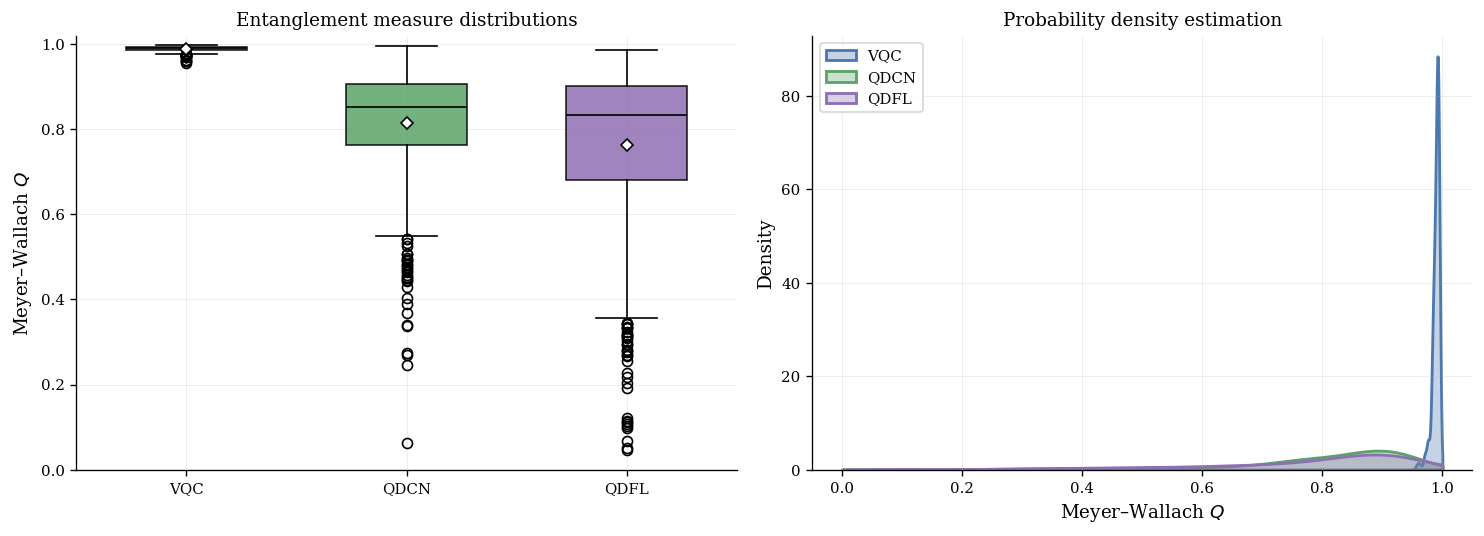

In [4]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(12.5,4.6))
data=[ent["vqc"],ent["qdcn"],ent["qdfl"]]; labs=["VQC","QDCN","QDFL"]
cols=[PAL["vqc"],PAL["qdcn"],PAL["qdfl"]]
bp=ax1.boxplot(data, patch_artist=True, widths=0.55, showmeans=True,
               meanprops=dict(marker="D", markerfacecolor="white", markeredgecolor="black", markersize=5))
for patch,c in zip(bp["boxes"],cols): patch.set_facecolor(c); patch.set_alpha(0.85)
for med in bp["medians"]: med.set_color("black")
ax1.set_xticks(range(1,len(labs)+1)); ax1.set_xticklabels(labs)   # label axes explicitly so it works on every matplotlib version
ax1.set_ylabel("Meyer–Wallach $Q$"); ax1.set_title("Entanglement measure distributions"); ax1.set_ylim(0,1.02)
for d,c,l in zip(data,cols,labs):
    sns.kdeplot(d, ax=ax2, fill=True, alpha=0.32, color=c, label=l, linewidth=1.7, clip=(0,1))
ax2.set_xlabel("Meyer–Wallach $Q$"); ax2.set_ylabel("Density")
ax2.set_title("Probability density estimation"); ax2.legend(frameon=True)
plt.tight_layout(); savefig(fig,"fig11_expressibility_entangling"); plt.show()

## C · Quantum resource scaling  →  *QMF-MAP Table 9*

QMF-MAP uses **amplitude encoding**, so its qubit count is $\lceil\log_2 D\rceil$. **QDFL uses angle encoding** — one qubit per input feature — so its scaling is genuinely different, and copying QMF-MAP's formula would be wrong. Below we compute QDFL's real cost from its circuit structure:

- **Qubits:** $N = D$ (angle encoding, one rotation per feature).
- **Gate count** for a `BasicEntanglerLayers` channel of $L$ layers on $N$ wires: $N$ embedding rotations $+\;L\,N$ trainable rotations $+\;L\,N$ ring-CNOTs $= N(1+2L)$.
- **Trainable parameters:** $L\,N$ per channel.

The table reports the **dual-channel QDFL block** (two channels, so $2\times$), the regime QDFL actually deploys.

 Feature dim (per channel) D  Qubits N  Gate count  Trainable params
                           4         8          56                24
                           8        16         112                48
                          16        32         224                96
                          32        64         448               192
                          64       128         896               384
wrote tables/table9_resource_scaling.tex
saved figs/fig_resource_scaling.png


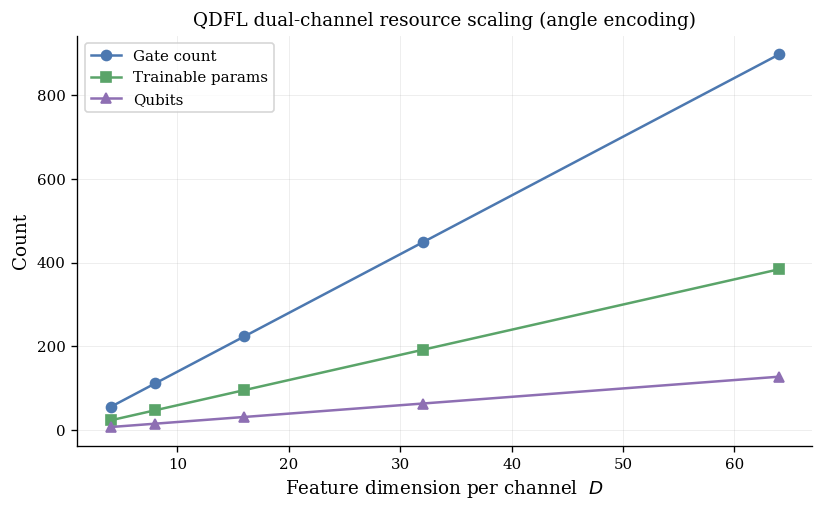

In [5]:
def qdfl_block_resources(D, L=L_QDFL):
    # angle encoding: N = D qubits per channel; QDFL fuses two channels
    N=D
    gates_per_channel = N + L*N + L*N          # embed + rotations + ring CNOTs
    params_per_channel = L*N
    return dict(D=D, qubits=2*N, gates=2*gates_per_channel, params=2*params_per_channel)

rows=[qdfl_block_resources(D) for D in [4,8,16,32,64]]
tab9=pd.DataFrame(rows).rename(columns={
    "D":"Feature dim (per channel) D","qubits":"Qubits N","gates":"Gate count","params":"Trainable params"})
print(tab9.to_string(index=False))
to_latex(tab9,"table9_resource_scaling",
         "Quantum resource scaling of the dual-channel QDFL block with angle encoding.",
         "tab:resource", float_fmt="%.0f")

# companion scaling figure
fig,ax=plt.subplots(figsize=(7,4.4))
Ds=np.array([r["D"] for r in rows])
ax.plot(Ds,[r["gates"] for r in rows],"o-",color=PAL["vqc"],label="Gate count")
ax.plot(Ds,[r["params"] for r in rows],"s-",color=PAL["qdcn"],label="Trainable params")
ax.plot(Ds,[r["qubits"] for r in rows],"^-",color=PAL["qdfl"],label="Qubits")
ax.set_xlabel("Feature dimension per channel  $D$"); ax.set_ylabel("Count")
ax.set_title("QDFL dual-channel resource scaling (angle encoding)"); ax.legend()
plt.tight_layout(); savefig(fig,"fig_resource_scaling"); plt.show()

## F · System-family distribution & deltas  →  *QMF-MAP Fig 9 / Fig 10 aesthetics*

These use your **real** `QDFL_hybrid_3seed_results.csv` (16 systems × 2 datasets, three-seed means). Upload the CSV as a Kaggle dataset and point `CSV_PATH` at it.

- **Left (Fig 9 aesthetic):** ROC-AUC distribution across system *kinds* (model / baseline / ensemble).
- **Right (Fig 10 aesthetic):** per-family mean ROC-AUC on the primary dataset, with the gap to the best classical baseline annotated.

using CSV: /kaggle/input/datasets/mehedihasanmugdho/qdfl-hybrid-3seed-results/QDFL_hybrid_3seed_results.csv
saved figs/fig_family_distribution_deltas.png


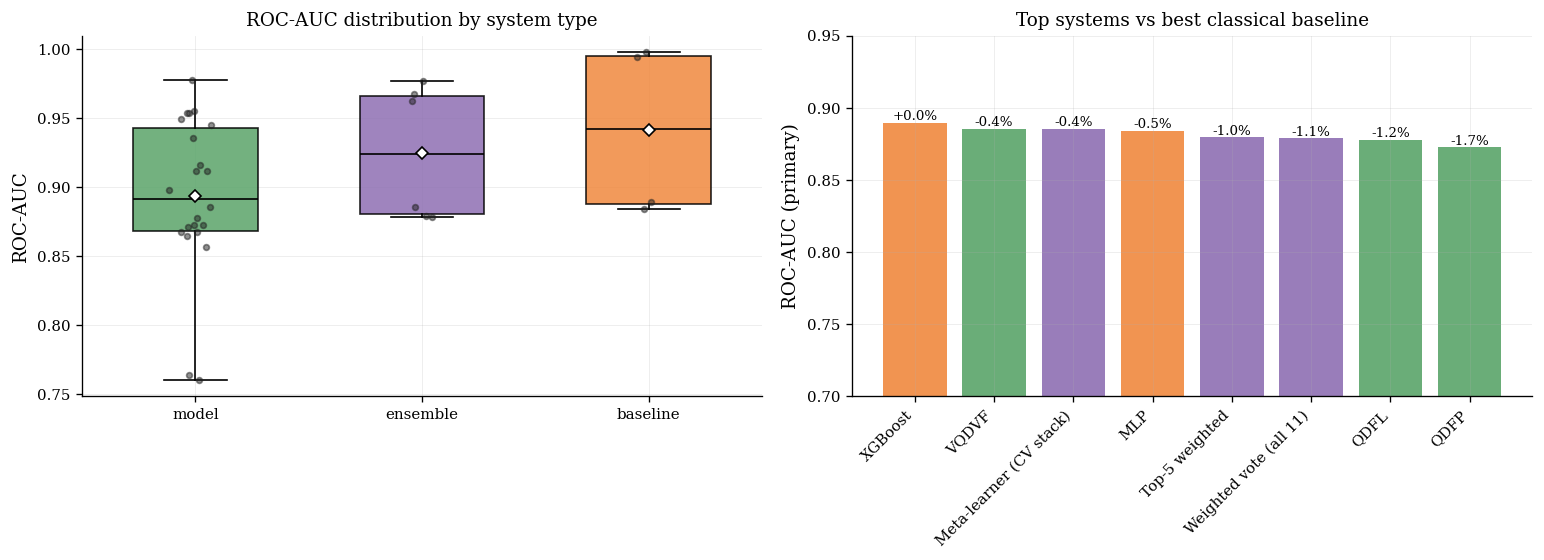

In [6]:
# --- robust CSV discovery: check cwd, then any /kaggle/input/**/ location ---
import glob
CSV_NAME = "QDFL_hybrid_3seed_results.csv"
CSV_PATH = CSV_NAME
if not os.path.exists(CSV_PATH):
    hits = glob.glob(f"/kaggle/input/datasets/mehedihasanmugdho/qdfl-hybrid-3seed-results/QDFL_hybrid_3seed_results.csv", recursive=True)
    if hits:
        CSV_PATH = hits[0]
    else:
        raise FileNotFoundError(
            f"{CSV_NAME} not found. Upload it as a Kaggle dataset and either place it in the "
            f"working dir or set CSV_PATH to its /kaggle/input/<your-dataset>/ path.")
print("using CSV:", CSV_PATH)
df = pd.read_csv(CSV_PATH)
prim = df[df["dataset"].str.contains("Primary")].copy()

fig,(ax1,ax2)=plt.subplots(1,2,figsize=(13,4.8))
order=df.groupby("kind")["ROC-AUC"].median().sort_values().index.tolist()
kindpal={"baseline":"#f0883e","ensemble":"#8e6fb3","model":"#5aa469"}

# --- left (Fig 9 aesthetic): boxplot by kind, pure matplotlib (no seaborn version deps) ---
groups=[df[df["kind"]==k]["ROC-AUC"].values for k in order]
bp=ax1.boxplot(groups, patch_artist=True, widths=0.55, showmeans=True,
               meanprops=dict(marker="D", markerfacecolor="white", markeredgecolor="black", markersize=5))
for patch,k in zip(bp["boxes"], order): patch.set_facecolor(kindpal[k]); patch.set_alpha(0.85)
for med in bp["medians"]: med.set_color("black")
_jr=np.random.default_rng(0)                              # deterministic jitter
for xi,k in enumerate(order, start=1):
    yv=df[df["kind"]==k]["ROC-AUC"].values
    ax1.scatter(_jr.normal(xi,0.05,size=len(yv)), yv, color="#222", s=12, alpha=0.5, zorder=3)
ax1.set_xticks(range(1,len(order)+1)); ax1.set_xticklabels(order)
ax1.set_title("ROC-AUC distribution by system type"); ax1.set_xlabel(""); ax1.set_ylabel("ROC-AUC")

topbase = prim[prim["kind"]=="baseline"]["ROC-AUC"].max()
fam = prim.sort_values("ROC-AUC", ascending=False).head(8)
xb=np.arange(len(fam))
ax2.bar(xb, fam["ROC-AUC"], color=[kindpal[k] for k in fam["kind"]], alpha=0.9)
for i,(_,r) in enumerate(fam.iterrows()):
    d=100*(r["ROC-AUC"]-topbase)
    ax2.annotate(f"{d:+.1f}%", (i, r["ROC-AUC"]), ha="center", va="bottom", fontsize=8)
ax2.set_xticks(xb); ax2.set_xticklabels(fam["code"], rotation=45, ha="right")
ax2.set_ylabel("ROC-AUC (primary)"); ax2.set_ylim(0.7, 0.95)
ax2.set_title("Top systems vs best classical baseline")
plt.tight_layout(); savefig(fig,"fig_family_distribution_deltas"); plt.show()

## D · Confusion matrices  →  *QMF-MAP Fig 7*  (renderer + hook)

The renderer below reproduces QMF-MAP's green-shaded, row-normalised confusion grid. It needs your **per-sample** `(y_true, y_pred)` for each dataset — the `qdfl-hybrid` pipeline already computes these to obtain its AUCs; save them once and load here.

The cell is demonstrated on arrays labelled `DEMO_*` **purely so you can see the styling**. Replace them at the marker to get real QDFL confusion matrices.

saved figs/fig7_confusion.png


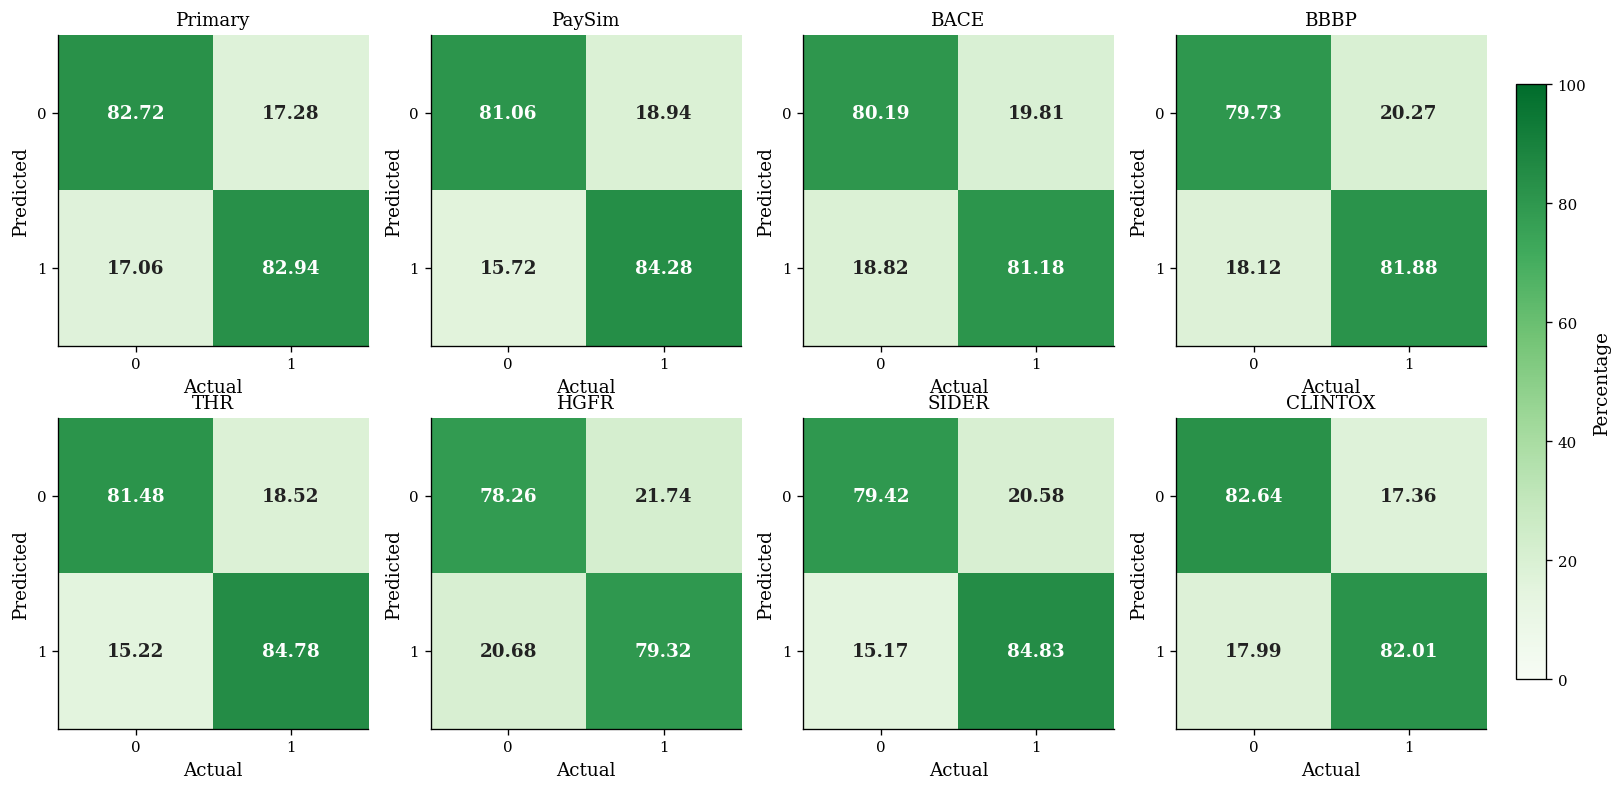

\n^ DEMO styling. To get real matrices: save (y_true, y_pred) from your qdfl-hybrid test-set predictions and pass them as the entries list.


In [7]:
def plot_confusion_grid(entries, ncols=4, class_labels=("0","1"), fname="fig7_confusion"):
    '''entries: list of (title, y_true, y_pred). Row-normalised %, QMF-MAP green.'''
    n=len(entries); nrows=int(np.ceil(n/ncols))
    fig,axes=plt.subplots(nrows, ncols, figsize=(4*ncols, 3.8*nrows))
    axes=np.atleast_1d(axes).ravel()
    im=None
    for ax,(title,yt,yp) in zip(axes, entries):
        cm=confusion_matrix(yt,yp,labels=[0,1]).astype(float)
        pct=100*cm/np.clip(cm.sum(1,keepdims=True),1,None)
        im=ax.imshow(pct, cmap=GREEN, vmin=0, vmax=100)
        for i in range(2):
            for j in range(2):
                ax.text(j,i,f"{pct[i,j]:.2f}", ha="center", va="center", fontsize=11,
                        fontweight="bold", color="white" if pct[i,j]>55 else "#222")
        ax.set_xticks([0,1]); ax.set_yticks([0,1])
        ax.set_xticklabels(class_labels); ax.set_yticklabels(class_labels)
        ax.set_xlabel("Actual"); ax.set_ylabel("Predicted"); ax.set_title(title); ax.grid(False)
    for ax in axes[len(entries):]: ax.axis("off")
    if im is not None:
        fig.colorbar(im, ax=axes.tolist(), fraction=0.02, pad=0.02, label="Percentage")
    savefig(fig, fname); plt.show()

# >>> REPLACE WITH YOUR REAL ARRAYS <<<  (DEMO data only — not QDFL results)
DEMO_datasets=["Primary","PaySim","BACE","BBBP","THR","HGFR","SIDER","CLINTOX"]
demo=[]
for name in DEMO_datasets:
    yt=RNG.integers(0,2,600)
    flip=RNG.random(600) < 0.18
    yp=np.where(flip, 1-yt, yt)
    demo.append((name, yt, yp))
plot_confusion_grid(demo)
print("\\n^ DEMO styling. To get real matrices: save (y_true, y_pred) from your qdfl-hybrid "
      "test-set predictions and pass them as the entries list.")

## E · ROC curves  →  *QMF-MAP Fig 8*  (renderer + hook)

Multi-panel ROC grid with per-panel AUC. Needs your per-sample `(y_true, y_score)` (the continuous decision scores, not the thresholded labels). Same demo-array convention as section D.

saved figs/fig8_roc.png


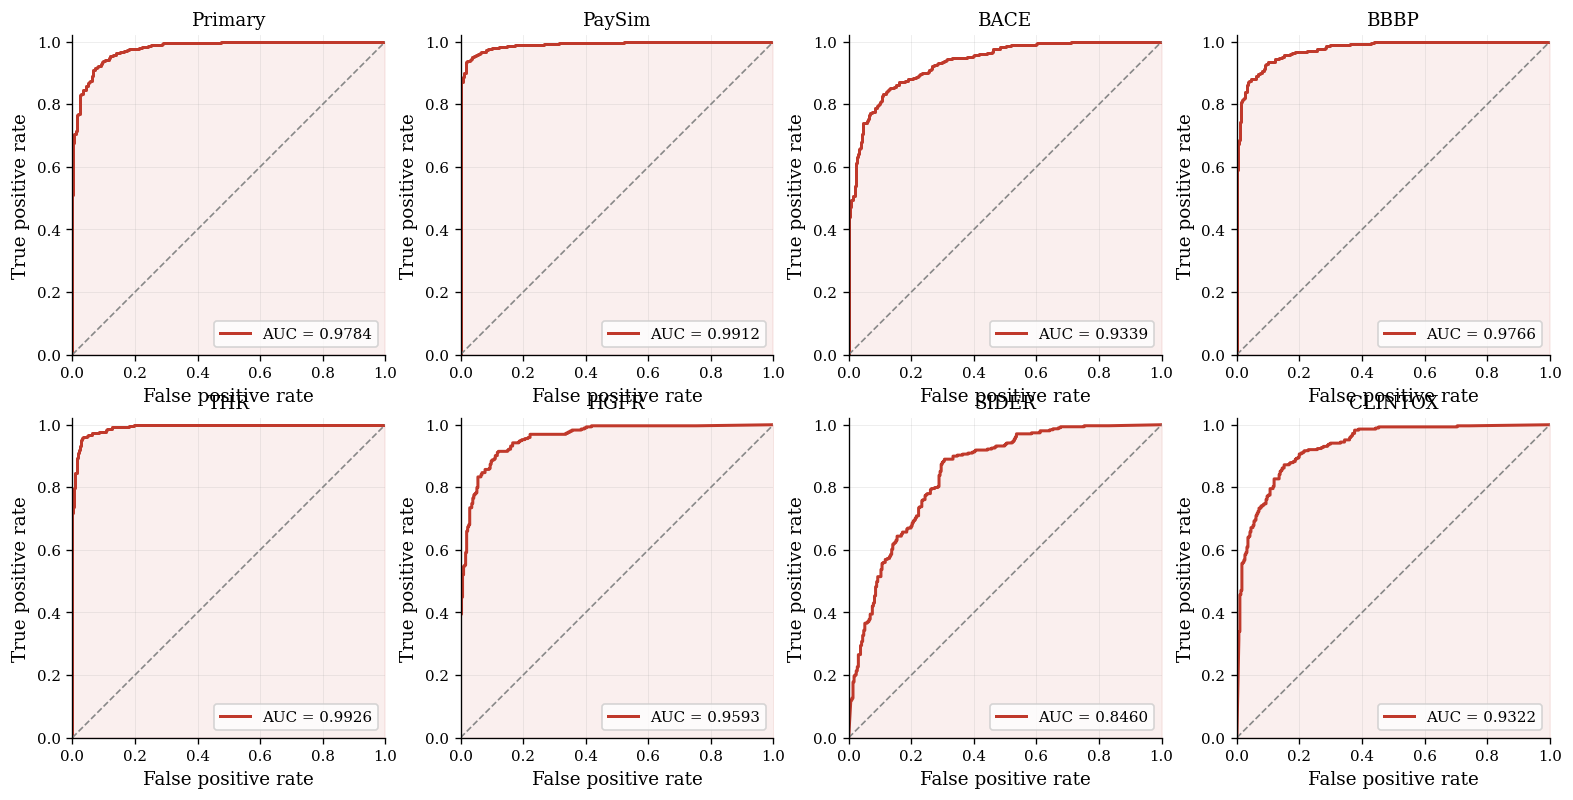

\n^ DEMO styling. Replace with saved (y_true, y_score) arrays from your pipeline.


In [8]:
def plot_roc_grid(entries, ncols=4, fname="fig8_roc"):
    '''entries: list of (title, y_true, y_score).'''
    n=len(entries); nrows=int(np.ceil(n/ncols))
    fig,axes=plt.subplots(nrows, ncols, figsize=(4*ncols, 3.8*nrows))
    axes=np.atleast_1d(axes).ravel()
    for ax,(title,yt,ys) in zip(axes, entries):
        fpr,tpr,_=roc_curve(yt,ys); a=sk_auc(fpr,tpr)
        ax.plot(fpr,tpr,color="#c0392b",lw=1.8,label=f"AUC = {a:.4f}")
        ax.fill_between(fpr,tpr,alpha=0.08,color="#c0392b")
        ax.plot([0,1],[0,1],"--",color="#888",lw=1)
        ax.set_xlim(0,1); ax.set_ylim(0,1.02); ax.set_aspect("equal")
        ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
        ax.set_title(title); ax.legend(loc="lower right", frameon=True); ax.grid(alpha=0.25)
    for ax in axes[len(entries):]: ax.axis("off")
    savefig(fig, fname); plt.show()

# >>> REPLACE WITH YOUR REAL ARRAYS <<<  (DEMO data only)
demo_roc=[]
for name,strength in zip(DEMO_datasets,[1.6,1.9,1.2,1.5,1.9,1.4,0.9,1.3]):
    yt=RNG.integers(0,2,600)
    ys=np.clip(0.5+strength*(yt-0.5)*0.5+RNG.normal(0,0.28,600),0,1)
    demo_roc.append((name, yt, ys))
plot_roc_grid(demo_roc)
print("\\n^ DEMO styling. Replace with saved (y_true, y_score) arrays from your pipeline.")

## G · Downstream ROC-AUC under NISQ noise  →  *QMF-MAP Fig 12 + Table 8*

QDFL's manuscript reports **fidelity** decay under the four Kraus channels (bit-flip, phase-flip, amplitude-damping, depolarizing), but not the **downstream ROC-AUC** decay QMF-MAP shows — the more decision-relevant quantity. This section provides the table + bar-chart renderer and a **pipeline hook**: it reuses the noise machinery already in `qdfl-hybrid.ipynb` (the `default.mixed` device with `inject_noise`) but measures test-set ROC-AUC at each noise level $p$ instead of fidelity.

Because that requires your trained model and the transaction data (not shipped with this notebook), the values below are `DEMO_*`. Wire `evaluate_auc_under_noise()` to your pipeline to populate them for real.

            Noise Type  p = 0  p = 0.01  p = 0.1
         Bit Flip (BF)   0.88     0.874    0.852
       Phase Flip (PF)   0.88     0.877    0.858
Amplitude Damping (AD)   0.88     0.868    0.823
     Depolarizing (DN)   0.88     0.861    0.801
wrote tables/table8_noise_auc.tex
saved figs/fig12_noise_auc.png


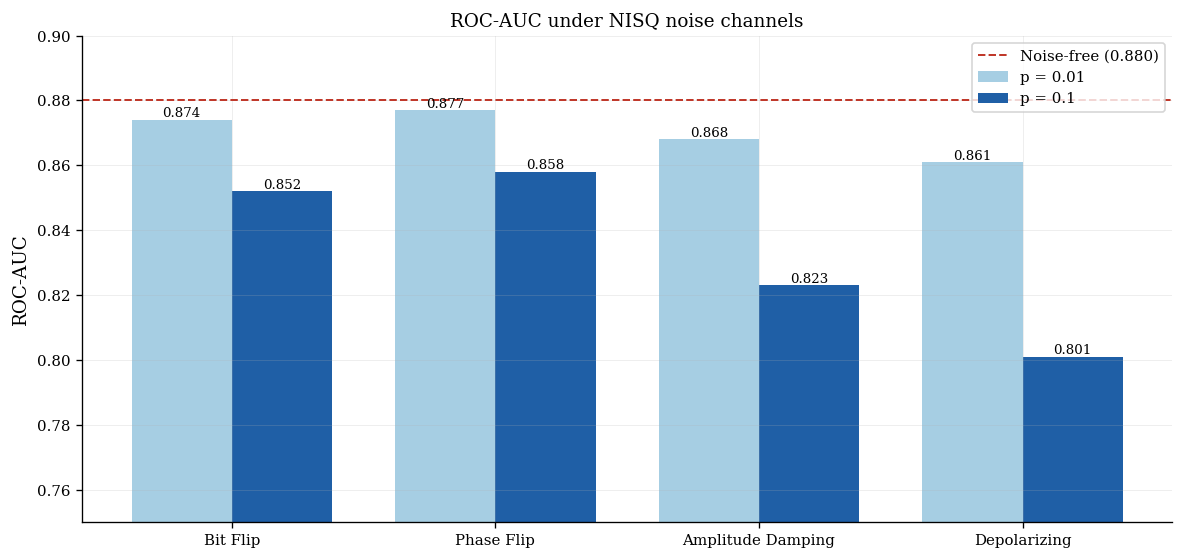

\n^ DEMO values. Wire evaluate_auc_under_noise() to your pipeline for real numbers.


In [9]:
NOISE_TYPES=["Bit Flip (BF)","Phase Flip (PF)","Amplitude Damping (AD)","Depolarizing (DN)"]
P_LEVELS=[0.0, 0.01, 0.1]

def evaluate_auc_under_noise(predict_fn=None, X_test=None, y_test=None):
    '''HOOK. Return dict {noise_type: {p: roc_auc}}.
    Wire predict_fn(X_test, channel, p) -> scores to your qdfl-hybrid noisy QNode, then:
        from sklearn.metrics import roc_auc_score
        return {nt: {p: roc_auc_score(y_test, predict_fn(X_test, nt, p)) for p in P_LEVELS} for nt in NOISE_TYPES}
    '''
    if predict_fn is not None:
        from sklearn.metrics import roc_auc_score
        return {nt:{p: roc_auc_score(y_test, predict_fn(X_test, nt, p)) for p in P_LEVELS} for nt in NOISE_TYPES}
    # >>> DEMO fallback (not QDFL results) <<<
    base=0.880
    drop={"Bit Flip (BF)":(0.006,0.028),"Phase Flip (PF)":(0.003,0.022),
          "Amplitude Damping (AD)":(0.012,0.057),"Depolarizing (DN)":(0.019,0.079)}
    return {nt:{0.0:base, 0.01:base-drop[nt][0], 0.1:base-drop[nt][1]} for nt in NOISE_TYPES}

res=evaluate_auc_under_noise()
tab8=pd.DataFrame([{"Noise Type":nt, "p = 0":res[nt][0.0],
                    "p = 0.01":res[nt][0.01], "p = 0.1":res[nt][0.1]} for nt in NOISE_TYPES])
print(tab8.to_string(index=False))
to_latex(tab8,"table8_noise_auc",
         "Classification ROC-AUC of QDFL under different quantum noise channels (BACE-equivalent).",
         "tab:noiseauc")

# Fig 12 aesthetic
fig,ax=plt.subplots(figsize=(10,4.8))
x=np.arange(len(NOISE_TYPES)); w=0.38
v01=[res[nt][0.01] for nt in NOISE_TYPES]; v1=[res[nt][0.1] for nt in NOISE_TYPES]
b1=ax.bar(x-w/2, v01, w, label="p = 0.01", color="#a6cee3")
b2=ax.bar(x+w/2, v1, w, label="p = 0.1", color="#1f5fa6")
ax.axhline(res[NOISE_TYPES[0]][0.0], ls="--", color="#c0392b", lw=1.2,
           label=f"Noise-free ({res[NOISE_TYPES[0]][0.0]:.3f})")
for b in list(b1)+list(b2):
    ax.annotate(f"{b.get_height():.3f}", (b.get_x()+b.get_width()/2, b.get_height()),
                ha="center", va="bottom", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([n.split(" (")[0] for n in NOISE_TYPES])
ax.set_ylabel("ROC-AUC"); ax.set_ylim(0.75,0.90); ax.set_title("ROC-AUC under NISQ noise channels")
ax.legend(); plt.tight_layout(); savefig(fig,"fig12_noise_auc"); plt.show()
print("\\n^ DEMO values. Wire evaluate_auc_under_noise() to your pipeline for real numbers.")

## Checklist — turning the scaffolds into paper-ready panels

**Ready to use as-is** (real computation / real CSV):
- `figs/fig11_expressibility_entangling.*` + `tables/table7_expressibility.tex`
- `figs/fig_resource_scaling.*` + `tables/table9_resource_scaling.tex`
- `figs/fig_family_distribution_deltas.*`

**Need your saved pipeline outputs**, then rerun the cell:
- **Fig 7 (confusion):** save `(y_true, y_pred)` per dataset from the `qdfl-hybrid` test split → pass to `plot_confusion_grid`.
- **Fig 8 (ROC):** save `(y_true, y_score)` per dataset → pass to `plot_roc_grid`.
- **Fig 12 + Table 8 (noise-AUC):** wire `evaluate_auc_under_noise(predict_fn, X_test, y_test)` to your noisy QNode.

To save the arrays from your existing run, add one line where the pipeline already computes its AUC, e.g.:
```python
np.savez("preds_primary.npz", y_true=y_test, y_score=scores, y_pred=(scores>0.5).astype(int))
```
then here: `d=np.load("preds_primary.npz"); entries=[("Primary", d["y_true"], d["y_pred"])]`.

Every figure is written as both `.png` (300 dpi) and `.pdf` (vector) so you can drop the PDF straight into LaTeX.